### MiddleWare

### Summarization Middleware

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
model=init_chat_model("groq:openai/gpt-oss-120b")

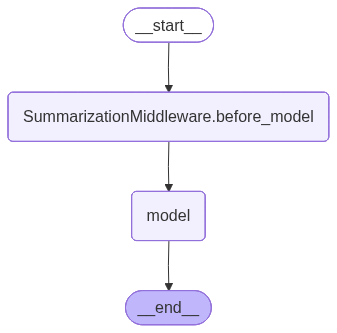

In [ ]:
from asyncio import taskgroups
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage,SystemMessage

## agent with Messagebased Summarisation
agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

agent

In [6]:
### thread id 
config={"configurable":{"thread_id":"test_1"}}

In [7]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 21/3?",
    "What is 2**3?",
    "What is 10-6?",
    "What is 8%5?",
]
for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages:{response}")
    print(f"Messages:{len(response['messages'])}")

Messages:{'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='aa16d398-7747-4534-a5bc-e398a63964d1'), AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'The user asks a simple math question: "What is 2+2?" Answer: 4.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 78, 'total_tokens': 119, 'completion_time': 0.08597005, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.003333035, 'prompt_tokens_details': None, 'queue_time': 0.282765713, 'total_time': 0.089303085}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_93703442d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f26c0-d83f-7d60-9e7d-50fe9adf38e3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 41, 'total_tokens': 119, 'output_token_details': {'reasoning': 22}})]}


### With the Help of TokenSize

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city:str)->str:
    """Search hotels - return long responses to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa , pool , gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star , $75/night, free wifi."""


agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("tokens",550),
            keep=("tokens",200)
        )
    ]
)

config={"configurable":{"thread_id":"test_1"}}

# Token Counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 #4 chars = 1 token 

In [10]:
#Run test
cities = ["Paris","London","Tokyo","New York","Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages":[HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )

    tokens=count_tokens(response["messages"])
    print(f"{city}: ~{tokens}, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~962, 6 messages
[HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nAssist the user in finding hotel options for multiple cities (Paris, London, Tokyo, and New\u202fYork), present key details, and enable follow‑up actions such as requesting more information, exploring additional categories, or checking availability and pricing.\n\n## SUMMARY\n- Executed `search_hotels` for **Paris**, **London**, **Tokyo**, and **New\u202fYork**, each returning three hotel options:\n  1. **Grand Hotel** – 5\u202f★, $350/night, amenities: spa, pool, gym, concierge, fine‑dining restaurant.\n  2. **City\u202fInn** – 4\u202f★, $180/night, amenities: business centre, free high‑speed Wi‑Fi, breakfast buffet, near subway/metro.\n  3. **Budget\u202fStay** – 3\u202f★, $75/night, amenities: free Wi‑Fi, 24‑hour front desk, easy public‑transport access.\n- Results for each city were presented in formatted tables.\n- Prompted the user to:\n  - Request detailed informat

### Fraction

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

#Low Fraction for testing
agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
        model=model,
        trigger=("fraction",0.005),
        keep=("fraction",0.002)
    ),
    ],
)

config={"configurable":{"thread_id":"test-1"}}

#Token Counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

#Test
cities = ["Paris","London","Tokyo","New York","Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages":[HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens=count_tokens(response["messages"])
    fraction = tokens / 128000
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])


Paris: ~145 tokens (0.1133%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='8caa899f-72aa-49f5-8ceb-8add11d04260'), AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants hotels in Paris. Use function search_hotels with city "Paris".', 'tool_calls': [{'id': 'fc_62f0631e-7145-4164-b340-87d4bdc0441d', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 120, 'total_tokens': 165, 'completion_time': 0.101221199, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.004696049, 'prompt_tokens_details': None, 'queue_time': 0.314017949, 'total_time': 0.105917248}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_60e4b492db', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f26df-cb40-78f2-979f-c8aecb4a30eb-0

### Human in the loop Middleware 

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) ->str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str)-> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject {subject}"

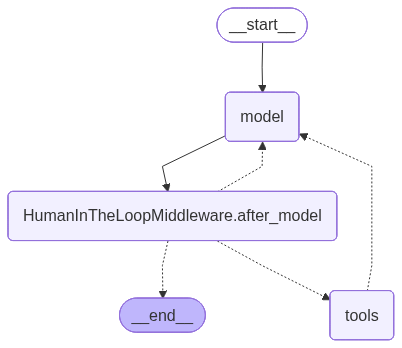

In [16]:
agent = create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)

agent

In [17]:
config ={"configurable":{"thread_id":"test-approve"}}
#Step 1 : Request
result =agent.invoke(
    {"messages":[HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How r u ?'" )]},
    config=config
)

In [18]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How r u ?'", additional_kwargs={}, response_metadata={}, id='6c96cdd1-857f-4233-adcf-331470137edf'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email via function. Use send_email_tool.', 'tool_calls': [{'id': 'fc_61ae9461-bf67-43a6-bb95-244082972fe8', 'function': {'arguments': '{"body":"How r u ?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 175, 'total_tokens': 236, 'completion_time': 0.129941869, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.007077139, 'prompt_tokens_details': None, 'queue_time': 0.286651613, 'total_time': 0.137019008}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_017482bd7f', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_pro

### Approve

In [19]:
from langgraph.types import Command

# Step 1 Approve

if "__interrupt__" in result:
    print("Approving")

    result = agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"approve"}
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Approving
Result: The email has been sent to **john@test.com** with the subject **“Hello”** and the body:

*How r u ?*


### Reject

In [26]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) ->str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str)-> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject {subject}"

agent = create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)



In [27]:
config ={"configurable":{"thread_id":"test-approve"}}
#Step 1 : Request
result =agent.invoke(
    {"messages":[HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How r u ?'" )]},
    config=config
)

In [28]:
#Step 2 : Rejecting it 
from langgraph.types import Command

if '__interrupt__' in result:
    print("Paused!! Approving...")

    result = agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"reject"}
                ]
            }
        ),config=config
    )

    print(f" Result: {result['messages'][-1].content}")

Paused!! Approving...
 Result: I’m unable to send the email right now because the request to use the email‑sending tool was declined. If you’d still like me to send that message, just let me know and I’ll try again!


### Editing

In [30]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) ->str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str)-> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject {subject}"

agent = create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)



In [31]:
config ={"configurable":{"thread_id":"test-approve"}}
#Step 1 : Request
result =agent.invoke(
    {"messages":[HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How r u ?'" )]},
    config=config
)

In [32]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How r u ?'", additional_kwargs={}, response_metadata={}, id='905a906a-651c-4060-b2a2-ae66c3a005ef'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send an email using send_email_tool. Provide body, recipient, subject.', 'tool_calls': [{'id': 'fc_3986745c-ae2c-498c-b01d-ef67faac164c', 'function': {'arguments': '{"body":"How r u ?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 175, 'total_tokens': 241, 'completion_time': 0.13883339, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.041264607, 'prompt_tokens_details': None, 'queue_time': 0.320794571, 'total_time': 0.180097997}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4140daa9c2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'log

In [35]:
# Step 3 : Edit and approve

if '__interrupt__' in result:
    print("Paused!! Editing..")

    result=agent.invoke(
            Command(
                resume={
                    "decisions":[
                        {
                            "type":"edit",
                            "edited_action": {
                                "name":"send_email_tool", #Tool Name
                                "args":{
                                    "recipient":"correct@email.com",
                                    "subject":"Corrected Subject",
                                    "body":"This was edited by human before sending."
                                }
                            }
                        }
                    ]
                }
            ),config=config
    )

    for m in reversed(result["messages"]):
        if m.content:
            print(f"Result: {m.content}")
            break

Paused!! Editing..
Result: Email sent to correct@email.com with subject Corrected Subject
